# Predicting 30-Day Hospital Readmission Risk using Machine Learning
### EECE 5644 Final Project
### Ansh Patel

## Introduction

Hospital readmissions within 30 days of discharge are an important problem in the healthcare industry. These are linked to higher costs, worse patient outcomes, resource management issues, and lower hospital efficiency overall. In this project, I used the Diabetes 130-US Hospitals dataset to build a machine learning model to predict whether a patient would be readmitted within 30 days of discharge. I framed this task as a binary classification problem, where encounters with readmission within 30 days were labeled as positive cases. 

To tackle this problem, I built a full machine learning pipeline that includes data understanding, exploratory data analysis, preprocessing, model training, hyperparameter tuning, and comparison to other published works. In this project, multiple models were evaluated and their performance was assessed using different metrics for imbalanced classification. 

## Data Understanding

### Data Observations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

data_spots = [
    Path("../data/diabetic_data.csv"),
    Path("./data/diabetic_data.csv"),
    Path("diabetic_data.csv")
]

df = None

for file_path in data_spots:
    if file_path.exists():
        df = pd.read_csv(file_path)
        break

if df is None:
    extra_matches = list(Path.cwd().rglob("diabetic_data.csv"))
    if len(extra_matches) > 0:
        df = pd.read_csv(extra_matches[0])
    else:
        raise FileNotFoundError("Couldn't find diabetic_data.csv from this notebook location.")

df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [2]:
#Check size
df.shape

(101766, 50)

In [3]:
#Check column names
df.columns.tolist()

['encounter_id',
 'patient_nbr',
 'race',
 'gender',
 'age',
 'weight',
 'admission_type_id',
 'discharge_disposition_id',
 'admission_source_id',
 'time_in_hospital',
 'payer_code',
 'medical_specialty',
 'num_lab_procedures',
 'num_procedures',
 'num_medications',
 'number_outpatient',
 'number_emergency',
 'number_inpatient',
 'diag_1',
 'diag_2',
 'diag_3',
 'number_diagnoses',
 'max_glu_serum',
 'A1Cresult',
 'metformin',
 'repaglinide',
 'nateglinide',
 'chlorpropamide',
 'glimepiride',
 'acetohexamide',
 'glipizide',
 'glyburide',
 'tolbutamide',
 'pioglitazone',
 'rosiglitazone',
 'acarbose',
 'miglitol',
 'troglitazone',
 'tolazamide',
 'examide',
 'citoglipton',
 'insulin',
 'glyburide-metformin',
 'glipizide-metformin',
 'glimepiride-pioglitazone',
 'metformin-rosiglitazone',
 'metformin-pioglitazone',
 'change',
 'diabetesMed',
 'readmitted']

In [4]:
#General info and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [5]:
#Summary stats
df.describe(include="all")

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
count,1.017660e+05,1.017660e+05,101766,101766,101766,101766,101766.000000,101766.000000,101766.000000,101766.000000,101766,101766,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766,101766,101766,101766.000000,5346,17018,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766
unique,NaN,NaN,6,3,10,10,NaN,NaN,NaN,NaN,18,73,NaN,NaN,NaN,NaN,NaN,NaN,717,749,790,NaN,3,3,4,4,4,4,4,2,4,4,2,4,4,4,4,2,3,1,1,4,4,2,2,2,2,2,2,3
top,NaN,NaN,Caucasian,Female,[70-80),?,NaN,NaN,NaN,NaN,?,?,NaN,NaN,NaN,NaN,NaN,NaN,428,276,250,NaN,Norm,>8,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
freq,NaN,NaN,76099,54708,26068,98569,NaN,NaN,NaN,NaN,40256,49949,NaN,NaN,NaN,NaN,NaN,NaN,6862,6752,11555,NaN,2597,8216,81778,100227,101063,101680,96575,101765,89080,91116,101743,94438,95401,101458,101728,101763,101727,101766,101766,47383,101060,101753,101765,101764,101765,54755,78363,54864
mean,1.652016e+08,5.433040e+07,NaN,NaN,NaN,NaN,2.024006,3.715642,5.754437,4.395987,NaN,NaN,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,NaN,NaN,NaN,7.422607,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,1.026403e+08,3.869636e+07,NaN,NaN,NaN,NaN,1.445403,5.280166,4.064081,2.985108,NaN,NaN,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,NaN,NaN,NaN,1.933600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.252200e+04,1.350000e+02,NaN,NaN,NaN,NaN,1.000000,1.000000,1.000000,1.000000,NaN,NaN,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,8.496119e+07,2.341322e+07,NaN,NaN,NaN,NaN,1.000000,1.000000,1.000000,2.000000,NaN,NaN,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,6.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,1.523890e+08,4.550514e+07,NaN,NaN,NaN,NaN,1.000000,1.000000,7.000000,4.000000,NaN,NaN,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,8.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,2.302709e+08,8.754595e+07,NaN,NaN,NaN,NaN,3.000000,4.000000,7.000000,6.000000,NaN,NaN,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,NaN,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Identify target variable

In [6]:
df["readmitted"].value_counts(dropna=False)

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

In [7]:
df["readmitted"].value_counts(normalize=True, dropna=False)

readmitted
NO     0.539119
>30    0.349282
<30    0.111599
Name: proportion, dtype: float64

### Check missing values

In [8]:
na_counts = df.isna().sum().sort_values(ascending=False)
na_counts.head(20)

max_glu_serum          96420
A1Cresult              84748
encounter_id               0
nateglinide                0
glimepiride                0
acetohexamide              0
glipizide                  0
glyburide                  0
tolbutamide                0
pioglitazone               0
rosiglitazone              0
acarbose                   0
miglitol                   0
troglitazone               0
tolazamide                 0
examide                    0
citoglipton                0
insulin                    0
glyburide-metformin        0
glipizide-metformin        0
dtype: int64

In [9]:
question_mark_counts = (df == "?").sum().sort_values(ascending=False)
question_mark_counts.head(20)

weight               98569
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
encounter_id             0
tolazamide               0
glyburide                0
tolbutamide              0
pioglitazone             0
rosiglitazone            0
acarbose                 0
miglitol                 0
troglitazone             0
citoglipton              0
examide                  0
acetohexamide            0
insulin                  0
dtype: int64

### Seperate categorical and numerical columns 

In [10]:
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("Categorical columns:", len(categorical_cols))
print("Numerical columns:", len(numerical_cols))
print("\nCategorical:", categorical_cols)
print("\nNumerical:", numerical_cols)

Categorical columns: 37
Numerical columns: 13

Categorical: ['race', 'gender', 'age', 'weight', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']

Numerical: ['encounter_id', 'patient_nbr', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']


### Inspect important columns

In [11]:
important_cols = [
    "readmitted",
    "age",
    "gender",
    "race",
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id",
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "diag_1",
    "diag_2",
    "diag_3"
]

for col in important_cols:
    if col not in df.columns:
        continue
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False).head(10))


readmitted
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

age
age
[70-80)     26068
[60-70)     22483
[50-60)     17256
[80-90)     17197
[40-50)      9685
[30-40)      3775
[90-100)     2793
[20-30)      1657
[10-20)       691
[0-10)        161
Name: count, dtype: int64

gender
gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64

race
race
Caucasian          76099
AfricanAmerican    19210
?                   2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64

admission_type_id
admission_type_id
1    53990
3    18869
2    18480
6     5291
5     4785
8      320
7       21
4       10
Name: count, dtype: int64

discharge_disposition_id
discharge_disposition_id
1     60234
3     13954
6     12902
18     3691
2      2128
22     1993
11     1642
5      1184
25      989
4       815
Name: count, dtype: int64

admission_source_id
admission_source_id
7    

### Initial Observations

- The dataset has 101,766 rows and 50 columns. There are 37 categorical features and 13 numerical features
- The target variable ‘readmitted’ has 3 classes. 11.2% of encounters fall into the <30 category meaning the final binary prediction task will be imbalanced
- There are many features that will help predict readmission such as ‘hospital stay length’, ‘number of medications’, ‘prior inpatient visits’, ‘diagnoses’, and ‘admission/discharge information’
- Missing data appears both as true null values and as ‘?’ Placeholders. These are especially prevalent in weight, payer_code, medical_speciality, max_glu_serum, and A1Cresult
- The dataset contains identifier columns that will need to be removed 
- Overall the dataset is large and relevant

## Exploratory Data Analysis

### Convert Target Variable 

In [12]:
#Make 30-day readmission flag
#Only the "<30" category counts towards positive case '1'
df["readmitted_binary"] = (df["readmitted"] == "<30").astype(int)
df["readmitted_binary"].value_counts()

readmitted_binary
0    90409
1    11357
Name: count, dtype: int64

### Plot Target Distribution

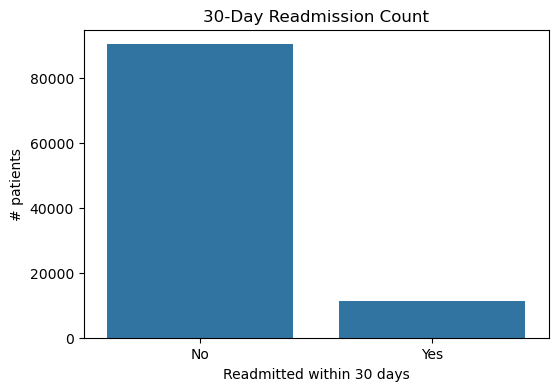

In [13]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="readmitted_binary")
plt.title("30-Day Readmission Count")
plt.xlabel("Readmitted within 30 days")
plt.ylabel("# patients")
plt.xticks([0, 1], ["No", "Yes"])
plt.show()

The dataset is very imbalanced. Roughly 10% of 30-Day readmissions were a positive case.

### Age vs Readmission

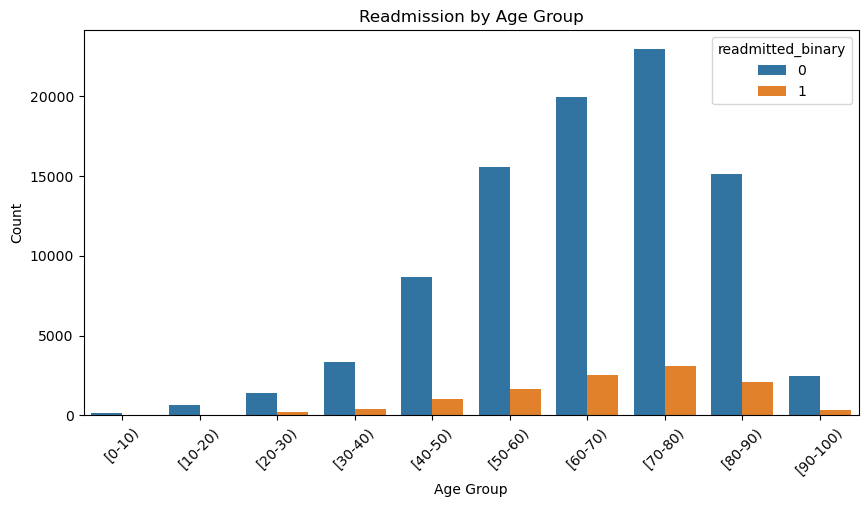

In [14]:
age_order = df["age"].dropna().unique()
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="age", hue="readmitted_binary", order=age_order)
plt.title("Readmission by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

### Time in Hospital vs Readmission

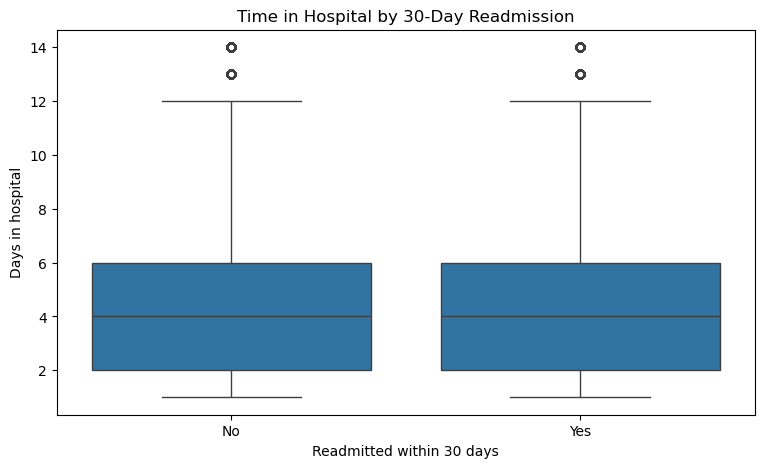

In [15]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="readmitted_binary", y="time_in_hospital")
plt.title("Time in Hospital by 30-Day Readmission")
plt.xlabel("Readmitted within 30 days")
plt.ylabel("Days in hospital")
plt.xticks([0, 1], ["No", "Yes"])
plt.show()

### Number of Medications vs Readmission

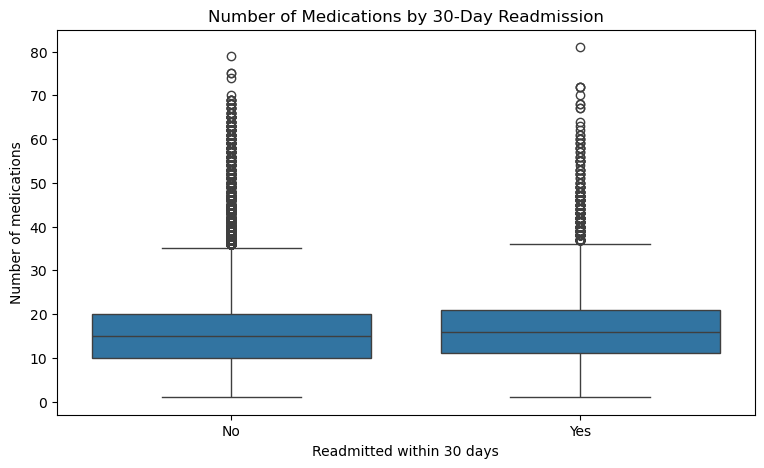

In [16]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="readmitted_binary", y="num_medications")
plt.title("Number of Medications by 30-Day Readmission")
plt.xlabel("Readmitted within 30 days")
plt.ylabel("Number of medications")
plt.xticks([0, 1], ["No", "Yes"])
plt.show()

### Prior Inpatient Visits

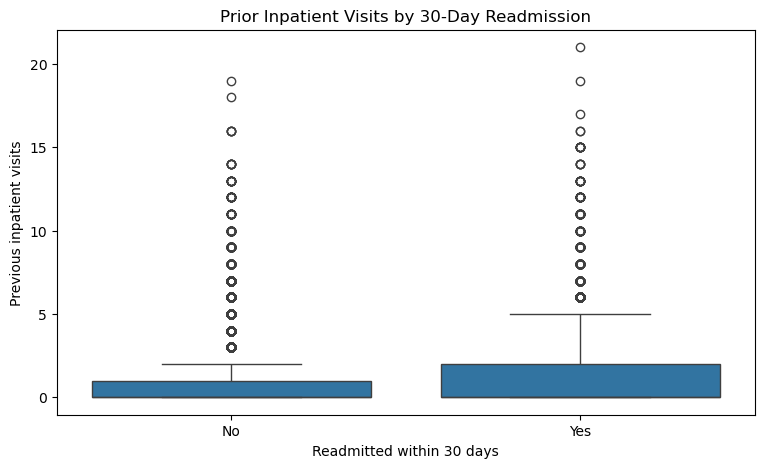

In [17]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="readmitted_binary", y="number_inpatient")
plt.title("Prior Inpatient Visits by 30-Day Readmission")
plt.xlabel("Readmitted within 30 days")
plt.ylabel("Previous inpatient visits")
plt.xticks([0, 1], ["No", "Yes"])
plt.show()

### Race Distribution for Readmission

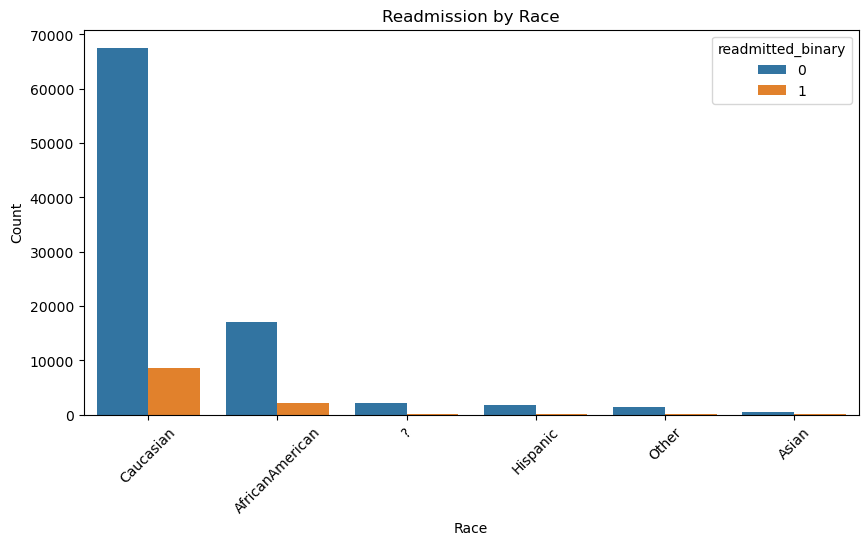

In [18]:
race_order = df["race"].value_counts(dropna=False).index
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="race", hue="readmitted_binary", order=race_order)
plt.title("Readmission by Race")
plt.xlabel("Race")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

### Numerical Correlation Heatmap

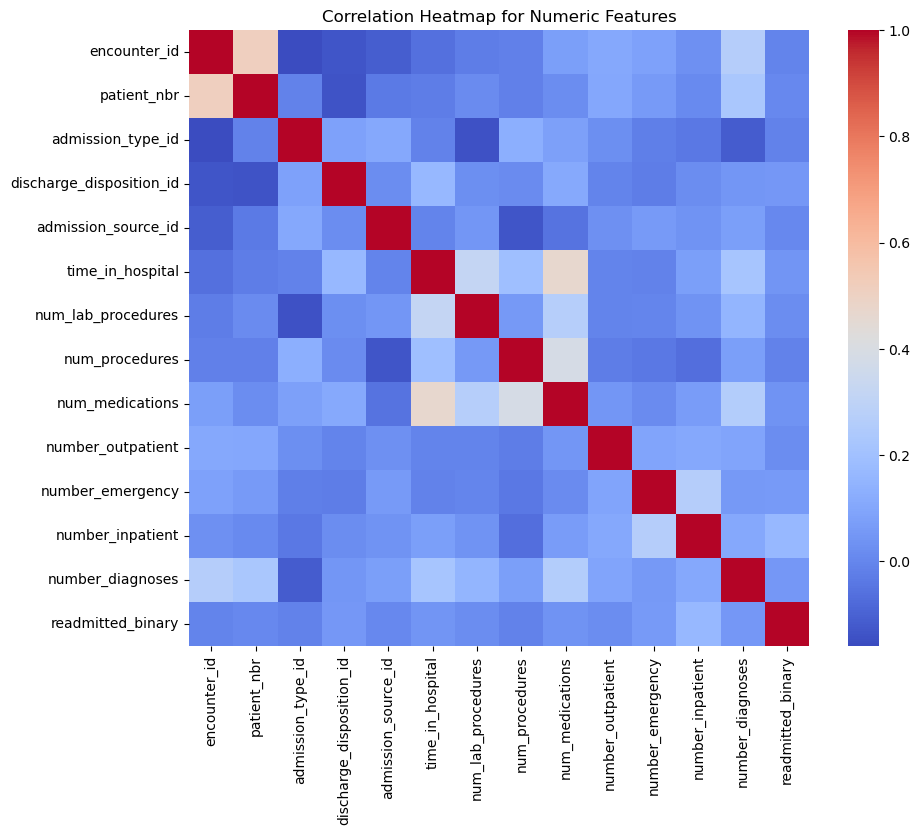

In [19]:
corr_vals = df[numerical_cols + ["readmitted_binary"]].corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_vals, cmap="coolwarm")
plt.title("Correlation Heatmap for Numeric Features")
plt.show()

### EDA Initial Findings

- The dataset is highly imbalanced, 90,409 non-readmissions and 11,357 30-day readmissions, thus accuracy won’t be a reliable metric alone
- Population is dominated by older patients especially for those between roughly 60 to 90 years old
- Readmissions appear most frequent in that older patient group
- Patient who were readmitted tend to have higher medication counts
- Prior inpatient visits show a clear difference between groups
- Patients who were readmitted tend to have longer hospital stays
- Race distribution is uneven
- Correlations between numerical features are weak with expected relationships such as longer stays being associated with more medications and procedures 
- These patterns suggest that utilization related features such as prior inpatient visits, medication count, and length of stay are likely to be strong predictors, which will be tested in the modeling phase. 

## Data Preprocessing

### Make a copy

In [20]:
df_model = df.copy()

# turn the original target into a binary one
df_model["readmitted_binary"] = (df_model["readmitted"] == "<30").astype(int)

# replace "?" with Nan
df_model = df_model.replace("?", np.nan)

df_model.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,readmitted_binary
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,NaN,NaN,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO,0
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30,0
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO,0
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO,0
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO,0


### Drop excess columns

In [21]:
# drop columns that are not useful for prediction and have too many missing values
drop_cols = [
    "encounter_id",
    "patient_nbr",
    "readmitted",
    "weight",
    "payer_code",
    "medical_specialty"
]

df_model = df_model.drop(columns=drop_cols, errors="ignore")

df_model.shape

(101766, 45)

### Check missing values after dropping extra columns

In [22]:
df_model.isna().sum().sort_values(ascending=False).head(15)

max_glu_serum    96420
A1Cresult        84748
race              2273
diag_3            1423
diag_2             358
diag_1              21
tolbutamide          0
pioglitazone         0
rosiglitazone        0
acarbose             0
miglitol             0
troglitazone         0
tolazamide           0
glipizide            0
examide              0
dtype: int64

### Define features and target

In [23]:
X = df_model.drop(columns=["readmitted_binary"])
y = df_model["readmitted_binary"]
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (101766, 44)
y shape: (101766,)


### Train/test split

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (81412, 44)
X_test: (20354, 44)
y_train: (81412,)
y_test: (20354,)


### Identify Feature Types post-cleaning

In [25]:
categorical_cols = X_train.select_dtypes(include="object").columns.tolist()
numerical_cols = X_train.select_dtypes(include=np.number).columns.tolist()
print("categorical colums:", len(categorical_cols))
print("numerical columns:", len(numerical_cols))

categorical colums: 33
numerical columns: 11


## Preprocessing Pipeline

In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [27]:
#Numerical Pipeline
num_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

num_pipe

#Categorical Pipeline
cat_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

cat_pipe

#Combine
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipe, numerical_cols),
        ("cat", cat_pipe, categorical_cols)
    ]
)

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['admission_type_id',
                                  'discharge_disposition_id',
                                  'admission_source_id', 'time_in_hospital',
                                  'num_lab_procedures', 'num_procedures',
                                  'num_medications', 'number_outpatient',
                                  'number_emergency', 'number_inpatient',
                                  'number_diagnoses...
                                  'diag_3', 'max_glu_serum', 'A1Cresult',
                                  'metformin', 'repaglinide', 'nateglinide',
                                  'chlorpropamide', 'glimepiride',
                                  'acetohexamide', 'glipizide', 'glyburide',
                                  'tolbutamide', 'pioglitazone',
                                  'rosiglitazone', 'acarbose', 'miglitol',
                                  'troglitazone', 'tolazamide', 'examide',
                                  'citoglipton', 'insulin',
                                  'glyburide-metformin', 'glipizide-metformin',
                                  'glimepiride-pioglitazone',
                                  'metformin-rosiglitazone', ...])])

### Test Preprocessing

In [28]:
train_ready = preprocessor.fit_transform(X_train)
test_ready = preprocessor.transform(X_test)

print("Train ready shape:", train_ready.shape)
print("Test ready shape:", test_ready.shape)

Train ready shape: (81412, 2275)
Test ready shape: (20354, 2275)


### Preprocessing Summary

- After creating the binary target and dropping selected columns the dataset had 101,766 rows and 45 columns
- Missing data including placeholder "?" were replaced with 'NaN'
- The final modeling setup used 44 input features and 1 target variable
- After the train/test splits done through stratified sampling, the dataset was divided into 81,412 training rows and 20,354 test rows
- The cleaned training features include 33 categoreical columns and 11 numerical columns 
- The preprocessing pipeline handled missing values, scaled numerical features, and one-hot encoded categorical features
- After preprocessing the training set had 81,412 rows and 2,275 features, while the test set had 20,354 rows and 2275 features


## Modeling and Initial Results

### Imports

In [29]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

### Baseline model

In [30]:
base_log_reg = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
])

base_log_reg

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['admission_type_id',
                                                   'discharge_disposition_id',
                                                   'admission_source_id',
                                                   'time_in_hospital',
                                                   'num_lab_procedures',
                                                   'num_procedures',
                                                   'num_medications',
                                                   'number_outpatient',
                                                   'number_emergency',
                                                   'num...
                                                   'acetohexamide', 'glipizide',
                                                   'glyburide', 'tolbutamide',
                                                   'pioglitazone',
                                                   'rosiglitazone', 'acarbose',
                                                   'miglitol', 'troglitazone',
                                                   'tolazamide', 'examide',
                                                   'citoglipton', 'insulin',
                                                   'glyburide-metformin',
                                                   'glipizide-metformin',
                                                   'glimepiride-pioglitazone',
                                                   'metformin-rosiglitazone', ...])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [31]:
#Fit baseline model
base_log_reg.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['admission_type_id',
                                                   'discharge_disposition_id',
                                                   'admission_source_id',
                                                   'time_in_hospital',
                                                   'num_lab_procedures',
                                                   'num_procedures',
                                                   'num_medications',
                                                   'number_outpatient',
                                                   'number_emergency',
                                                   'num...
                                                   'acetohexamide', 'glipizide',
                                                   'glyburide', 'tolbutamide',
                                                   'pioglitazone',
                                                   'rosiglitazone', 'acarbose',
                                                   'miglitol', 'troglitazone',
                                                   'tolazamide', 'examide',
                                                   'citoglipton', 'insulin',
                                                   'glyburide-metformin',
                                                   'glipizide-metformin',
                                                   'glimepiride-pioglitazone',
                                                   'metformin-rosiglitazone', ...])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [32]:
#Predictions for baseline model
pred_log = base_log_reg.predict(X_test)
prob_log = base_log_reg.predict_proba(X_test)[:, 1]

In [33]:
#Baseline metrics
print("Accuracy:", round(accuracy_score(y_test, pred_log), 4))
print("Precision:", round(precision_score(y_test, pred_log, zero_division=0), 4))
print("Recall:", round(recall_score(y_test, pred_log, zero_division=0), 4))
print("F1 Score:", round(f1_score(y_test, pred_log, zero_division=0), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, prob_log), 4))

Accuracy: 0.6454
Precision: 0.1677
Recall: 0.5495
F1 Score: 0.2569
ROC-AUC: 0.6428


In [34]:
#Confusion Matrix for baseline model
print(confusion_matrix(y_test, pred_log))

[[11888  6195]
 [ 1023  1248]]


### Define Model Pipeline

In [35]:
models = {
    "Logistic Regression": Pipeline([
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
    ]),
    
    "Decision Tree": Pipeline([
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(class_weight="balanced", random_state=42))
    ]),
    
    "Random Forest": Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=100,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]),
    
    "Gradient Boosting": Pipeline([
        ("preprocessor", preprocessor),
        ("model", GradientBoostingClassifier(random_state=42))
    ]),
    
    "KNN": Pipeline([
        ("preprocessor", preprocessor),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ]),
    
    "Neural Network": Pipeline([
        ("preprocessor", preprocessor),
        ("model", MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300, random_state=42))
    ])
}

### Train and evaluate models

In [ ]:
results = []

for name, model in models.items():
    print("Running:", name)
    
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_test)[:, 1]
        roc = roc_auc_score(y_test, probs)
    else:
        roc = np.nan
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds, zero_division=0),
        "Recall": recall_score(y_test, preds, zero_division=0),
        "F1 Score": f1_score(y_test, preds, zero_division=0),
        "ROC-AUC": roc
    })


Running: Logistic Regression
Running: Decision Tree
Running: Random Forest
Running: Gradient Boosting
Running: KNN
Running: Neural Network


### Results table

This table compares the untuned performance of all initial models. Since this dataset is imbalanced, the F1 score and ROC-AUC are better indicators than accuracy.

In [ ]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("F1 Score", ascending=False).reset_index(drop=True)
results_df.round(4)


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.6454,0.1677,0.5495,0.2569,0.6428
1,Decision Tree,0.7914,0.1610,0.2065,0.1809,0.5357
2,Neural Network,0.8051,0.1482,0.1572,0.1526,0.5441
3,KNN,0.8788,0.2662,0.0489,0.0826,0.5705
4,Gradient Boosting,0.8885,0.5294,0.0079,0.0156,0.6776
5,Random Forest,0.8887,0.6667,0.0053,0.0105,0.6537


### Initial Model Performance Observations

- Logistic Regression performed the best with an F1 score of 0.2569 and ROC-AUC of 0.6428. It also had a higher recall meaning that more positive cases were captured
- Gradient boosting achieved the best ROC-AUC of 0.6776 with a very low recall meaning it identified only a few actual readmissions. This made its F1 score much worse
- Random Forest showed a similar pattern to Gradient Boosting with high accuracy but very low recall and F1 score. It could be biased towards predicting the majority class
- Decision Tree, Neural network, and KNN did not perform well overall. KNN had high accuracy but very low recall showing that accuracy alone is misleading for this imbalanced dataset
- Overall the results show that for this readmission task, Logistic Regression provides the best balance between identifying positive cases and maintaing overall discrimination at the moment. Some of the other complex models appeared to struggle with the imbalanced dataset. 

## Hyperparameter tuning

In [ ]:
from sklearn.model_selection import GridSearchCV

### Tuning pipeline for Logistic Regression

In [ ]:
tune_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])


### Parameter Grid

In [ ]:
param_grid = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__solver": ["liblinear", "lbfgs"]
}

### GridSearchCV

In [ ]:
grid = GridSearchCV(
    estimator=tune_pipe,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['admission_type_id',
                                                                          'discharge_disposition_id',
                                                                          'admission_source_id',
                                                                          'time_in_hospital',
                                                                          'num_lab_procedures',
                                                                          'num_procedures',
                                                                          'num_medications',
                                                                          'number_outpati...
                                                                          'tolazamide',
                                                                          'examide',
                                                                          'citoglipton',
                                                                          'insulin',
                                                                          'glyburide-metformin',
                                                                          'glipizide-metformin',
                                                                          'glimepiride-pioglitazone',
                                                                          'metformin-rosiglitazone', ...])])),
                                       ('model',
                                        LogisticRegression(class_weight='balanced',
                                                           max_iter=1000,
                                                           random_state=42))]),
             n_jobs=-1,
             param_grid={'model__C': [0.01, 0.1, 1, 10],
                         'model__solver': ['liblinear', 'lbfgs']},
             scoring='f1', verbose=1)

### Compare best parameters and CV score

In [ ]:
print("best params:", grid.best_params_)
print("best cv score:", round(grid.best_score_, 4))

best params: {'model__C': 0.01, 'model__solver': 'lbfgs'}
best cv score: 0.258


### Evaluate Tuned Model on Test Set

In [ ]:
best_lr = grid.best_estimator_

y_pred_tuned = best_lr.predict(X_test)
y_prob_tuned = best_lr.predict_proba(X_test)[:, 1]

tuned_results = {
    "Model": "Tuned Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred_tuned),
    "Precision": precision_score(y_test, y_pred_tuned, zero_division=0),
    "Recall": recall_score(y_test, y_pred_tuned, zero_division=0),
    "F1 Score": f1_score(y_test, y_pred_tuned, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_prob_tuned)
}

pd.DataFrame([tuned_results]).round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Tuned Logistic Regression,0.6638,0.1764,0.5487,0.267,0.6591


### Compare Tuned vs Untuned

Logistic Regression was selected for hyperparameter tuning since it achieved the strongest initial balance of recall, F1 score, and interpretability.

In [ ]:
untuned_results = {
    "Model": "Untuned Logistic Regression",
    "Accuracy": accuracy_score(y_test, pred_log),
    "Precision": precision_score(y_test, pred_log, zero_division=0),
    "Recall": recall_score(y_test, pred_log, zero_division=0),
    "F1 Score": f1_score(y_test, pred_log, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, prob_log)
}

compare_df = pd.DataFrame([untuned_results, tuned_results])
compare_df = compare_df.set_index("Model")

compare_df.round(4)

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Model,,,,,
Untuned Logistic Regression,0.6454,0.1677,0.5495,0.2569,0.6428
Tuned Logistic Regression,0.6638,0.1764,0.5487,0.2670,0.6591


### Hyperparameter Tuning Observations

- A 5 fold GridSearchCV was used to tune Logistic Regression over 8 different parameter combinations for a total of 40 fits. The best configuration we saw was C = 0.01with the lbfgs solver
- The tuned models achieved slightly better F1 score, accuracy, precision, and ROC-AUC than the untuned Logistic Regression model. The results were 0.2670 vs 0.2569, 0.6638 vs 0.6454, 0.1764 vs 0.1677, and 0.6591 vs 0.6428 respectively 
- Recall decreased slightly from 0.5495 to 0.5487, thus the tuned model became a bit more balanced rather than maximizing positive predictions
- Overall the tuning produced a slight improvement meaning that Logistic Regression is well suited for the task and that performance may be more constrained by the dataset’s class imbalance and feature limitations than by initial parameter settings 

## Model Interpretation and Feature Importance

### Best Tuned Model

In [ ]:
best_lr = grid.best_estimator_
best_lr

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['admission_type_id',
                                                   'discharge_disposition_id',
                                                   'admission_source_id',
                                                   'time_in_hospital',
                                                   'num_lab_procedures',
                                                   'num_procedures',
                                                   'num_medications',
                                                   'number_outpatient',
                                                   'number_emergency',
                                                   'num...
                                                   'acetohexamide', 'glipizide',
                                                   'glyburide', 'tolbutamide',
                                                   'pioglitazone',
                                                   'rosiglitazone', 'acarbose',
                                                   'miglitol', 'troglitazone',
                                                   'tolazamide', 'examide',
                                                   'citoglipton', 'insulin',
                                                   'glyburide-metformin',
                                                   'glipizide-metformin',
                                                   'glimepiride-pioglitazone',
                                                   'metformin-rosiglitazone', ...])])),
                ('model',
                 LogisticRegression(C=0.01, class_weight='balanced',
                                    max_iter=1000, random_state=42))])

### Extract fitted preprocessor and model

In [ ]:
fit_pre = best_lr.named_steps["preprocessor"]
fit_model = best_lr.named_steps["model"]

### Get transformed feature names

In [ ]:
feat_names = fit_pre.get_feature_names_out()
print("number of transformed features:", len(feat_names))
print(feat_names[:10])

number of transformed features: 2275
['num__admission_type_id' 'num__discharge_disposition_id'
 'num__admission_source_id' 'num__time_in_hospital'
 'num__num_lab_procedures' 'num__num_procedures' 'num__num_medications'
 'num__number_outpatient' 'num__number_emergency' 'num__number_inpatient']


### Extract coefficients

In [ ]:
coefs = fit_model.coef_[0]
print("number of coefficients:", len(coefs))
print(coefs[:10])

number of coefficients: 2275
[-0.02403322  0.11990965 -0.00595895  0.04005607  0.00965565 -0.04154456
  0.03675877 -0.00664557  0.06282278  0.34306797]


### Build Feature Importance Table

In [ ]:
feat_imp = pd.DataFrame({
    "feature": feat_names,
    "coefficient": coefs
})

feat_imp["abs_value"] = feat_imp["coefficient"].abs()
feat_imp = feat_imp.sort_values("abs_value", ascending=False).reset_index(drop=True)

feat_imp.head(15)

,feature,coefficient,abs_value
0,cat__diag_1_V58,0.576386,0.576386
1,cat__diag_3_250.6,0.361306,0.361306
2,cat__diag_1_434,0.353456,0.353456
3,num__number_inpatient,0.343068,0.343068
4,cat__diag_1_486,-0.302297,0.302297
5,cat__diag_2_272,-0.287466,0.287466
6,cat__diag_1_440,0.281146,0.281146
7,cat__diag_1_786,-0.257791,0.257791
8,cat__diag_1_250.02,-0.256864,0.256864
9,cat__diag_2_342,0.245312,0.245312


### Seperate positive and negative predictors

To best understand why the tuned Logistic Regression model made its predictions, I evaluated the largest positive and negative coefficients after preprocessing and one-hot encoding.

In [ ]:
top_pos = feat_imp.sort_values("coefficient", ascending=False).head(10)
top_pos

,feature,coefficient,abs_value
0,cat__diag_1_V58,0.576386,0.576386
1,cat__diag_3_250.6,0.361306,0.361306
2,cat__diag_1_434,0.353456,0.353456
3,num__number_inpatient,0.343068,0.343068
6,cat__diag_1_440,0.281146,0.281146
9,cat__diag_2_342,0.245312,0.245312
10,cat__diag_1_250.6,0.240806,0.240806
12,cat__diag_1_787,0.225816,0.225816
13,cat__diag_1_820,0.224363,0.224363
15,cat__diag_1_443,0.220891,0.220891


### Top positive predictors

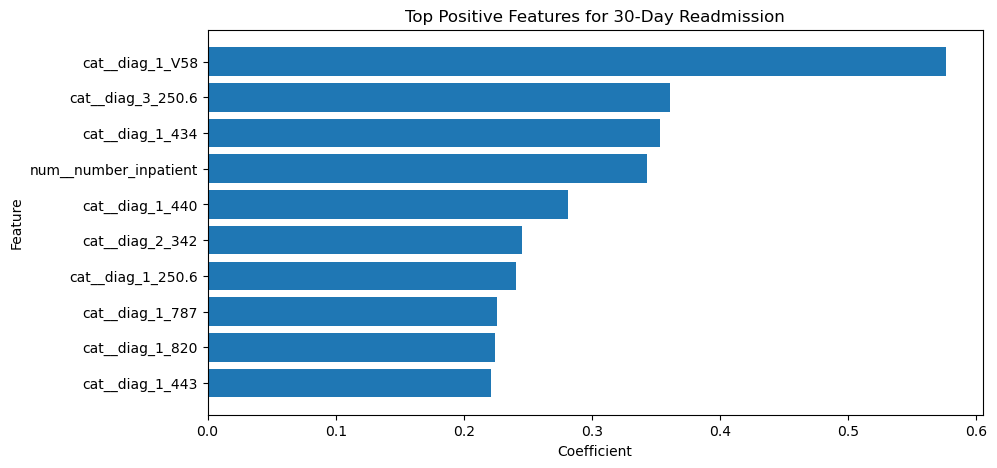

In [ ]:
plt.figure(figsize=(10, 5))
plt.barh(top_pos["feature"], top_pos["coefficient"])
plt.title("Top Positive Features for 30-Day Readmission")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()

### Top Negative Predictors

In [ ]:
top_neg = feat_imp.sort_values("coefficient", ascending=True).head(10)
top_neg

,feature,coefficient,abs_value
4,cat__diag_1_486,-0.302297,0.302297
5,cat__diag_2_272,-0.287466,0.287466
7,cat__diag_1_786,-0.257791,0.257791
8,cat__diag_1_250.02,-0.256864,0.256864
11,cat__age_[10-20),-0.226782,0.226782
14,cat__diag_1_997,-0.224243,0.224243
16,cat__diag_2_507,-0.216735,0.216735
17,cat__diag_1_518,-0.212104,0.212104
19,cat__diag_2_648,-0.207723,0.207723
20,cat__diag_1_722,-0.205587,0.205587


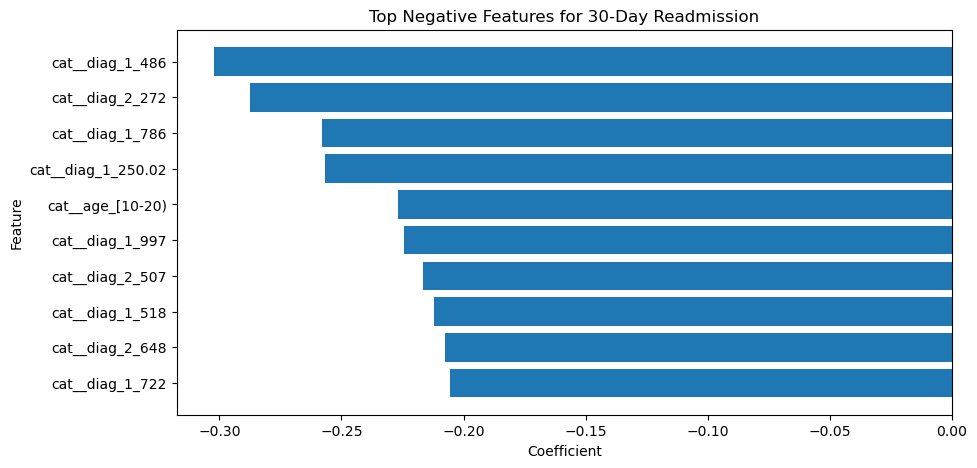

In [ ]:
plt.figure(figsize=(10, 5))
plt.barh(top_neg["feature"], top_neg["coefficient"])
plt.title("Top Negative Features for 30-Day Readmission")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()

### Top Influential Features

In [ ]:
feat_imp.head(15)

,feature,coefficient,abs_value
0,cat__diag_1_V58,0.576386,0.576386
1,cat__diag_3_250.6,0.361306,0.361306
2,cat__diag_1_434,0.353456,0.353456
3,num__number_inpatient,0.343068,0.343068
4,cat__diag_1_486,-0.302297,0.302297
5,cat__diag_2_272,-0.287466,0.287466
6,cat__diag_1_440,0.281146,0.281146
7,cat__diag_1_786,-0.257791,0.257791
8,cat__diag_1_250.02,-0.256864,0.256864
9,cat__diag_2_342,0.245312,0.245312


### Model Interpretation

- The tuned Logistic Regression was used for interpretation as it gave the best balance of results for this imbalanced dataset
- After preprocessing and one-hot encoding, the model had 2275 transformed features
- One of the clearest positive predictors was ‘number_inpatient’ suggesting that patients with more prior inpatient visits were more likely to be readmitted
- Many of the strongest positive and negative predictors were diagnosis related one-hot encoded features such as ‘diag_1’ which suggests that diagnosis history mattered
- Other diagnosis codes also had very strong positive coefficients while other had strong negative coefficients
- The age category ‘age_[10-20)’ had a negative coefficient, suggesting that this group was less likely to be predicted as readmitted
- Overall the model seems to rely on prior utilization and diagnosis features rather than demographics
- These coefficients explain how the model makes prediction but should be interpreted as association in the model rather than effect

## Final Model Evaluation

### Confusion Matrix for Best Performing Model (Tuned Logistic Regression)

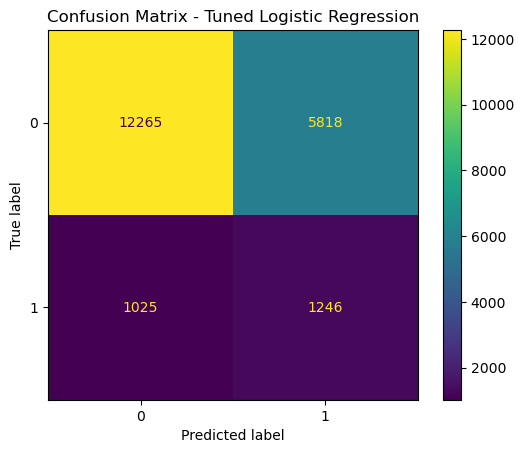

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tuned)
plt.title("Confusion Matrix - Tuned Logistic Regression")
plt.show()

The confusion matrix shows that tuned logistic regression was able to identify some patient who were readmitted within 30 days, but still produced both false positives and negatives. This is expected since the dataset is highly imbalanced. Overall this suggests that the model has predictive value, but is not highly precise in separating all positive and negative cases. Which is why it is important to factor in other metrics. 

### ROC Curve

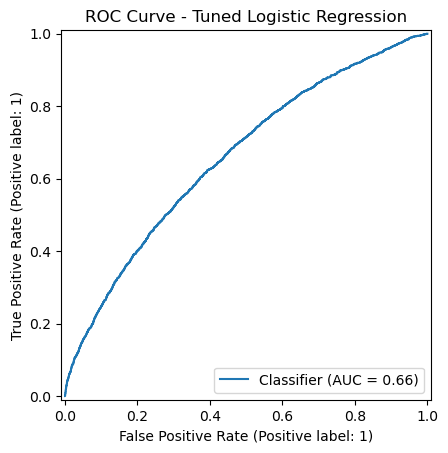

In [ ]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_test, y_prob_tuned)
plt.title("ROC Curve - Tuned Logistic Regression")
plt.show()

The ROC curve shows that the model performs better than random guessing and has some ability to separate the two classes. However, the curve shows there is room for improvement. Overall, the tuned Logistic regression model provides a decent balance between performance and interpretability. 

## Comparison To Existing Work and Real World Impact

The Diabetes 130-US Hospital dataset is widely used for readmission prediction research. According to the UCI repo, the dataset contains 101,766 hospital encounters from 130 hospitals over a ten year period spanning from 1999 to 2008 and was designed to study early readmission within 30 days. 

Recent research has used this dataset and similar diabetic readmissions to compare traditional and machine learning methods. In one study from 2025, they used logistic regression, random forest, XGBoost, and neural networks for 30 day diabetic readmission predictions. Another 2024 study examined bias, fairness, and subgroup performance of 30 day readmission models. 

My results were pretty similar to prior studies that found predictive performance was moderate. In this project, untuned Logistic regression produced the best initial F1 score, while Gradient Boosting had the best initial ROC-AUC. However, after tuning, logistic regression remained the strongest overall model improving F1 from 0.2569 to 0.2670 and ROC-AUC from 0.6428 to 0.6591. My results suggests simpler and more interpretable model can remain competitive with more complex methods, especially when the target is highly imbalanced. 

An important takeaway is that higher accuracy did not mean better performance on the readmission task. Some complex models such as Random Forest and Gradient Boosting achieved high accuracy but with very low recall for the positive class. This limited the efficiency in finding patients that were truly at risk of 30 day readmission. However, simpler models like Logistic Regression offered the best balance between performance and interpretability. 

## Real World and Social Impact

A model to prentice 30 day hospital readmissions is very useful as it can help hospitals better prioritize resources, identify patients that require stronger discharge planning, earlier follow ups, and additional care. The tasks are tied to a real clinical problem because the UCI dataset is created specifically around early readmissions in diabetic patients. 

A model for predicting 30 day hospital readmission is useful in practice since it may help hospitals identify patients who need stronger discharge planning, medication review, earlier follow-ups and additional care coordination. The task is tied to a real clinical and operational problem since because the UCI dataset is created specifically around early readmission in diabetic inpatient encounters. 

There are important ethical concerns with this prediction model. Firstly, the data is highly imbalanced where roughly 10% of encounters belong to the 30 day readmission class. Meaning there is a risk that a model could favor the majority class and still appear relatively accurate. Secondly, the UCI dataset includes sensitive demographics such as age, gender, and race, which leads to fairness concerns being relevant. The repository notes that the pretense of sensitive variables and that recent studies have examined bias in many of the 30 day readmission models.

Overall, my results further reinforce this. Certain demographics lead to increase in bias for the model, thus they should not be interpreted as normal driving factors for readmission. These demographic may reflect on broader patterns in healthcare access, disease burden, and documentation. A model for an issue such as thus should be used as a decision support aid instead of the final say for if a patient will be readmitted in 30 days. This allows hospitals to prioritize resources and clinicians are given the final judgment.

## Impact Summary

- A confusion matrix and ROC curve were generated for the tuned Logistic Regression model
- Existing work on the dataset shows that hospital readmission prediction is well studied, but difficult to be precise with Results show only moderate predictive performance
- My results were consistent with this pattern, with tuned Logistic Regression performing best and slightly improving the untuned baseline
- In the real world, the model can support discharge planning and follow up prioritization. However, with factors such as fairness and bias in play, the model should only be used as a decision support tool

## Conclusion

This project explored the problem of predicting 30-day hospital readmission using the Diabetes 130-US Hospital dataset. I did this by building a complete machine learning pipeline that includes: data preprocessing, exploratory data analysis, model comparison, and hyperparameter tuning. From this, I found that Logistic Regression produced the best overall balance in performance for an imbalanced dataset such as this. For my results, I was able to conclude that while some of the more complex models, such as KNN and Neural Networks, achieved higher accuracies and ROC-AUC scores, they performed worse at actually identifying positive cases. In contrast, a simpler model, such as Logistic Regression, performed the best because it’s able to handle the imbalanced dataset more efficiently, while avoiding overfitting.

In conclusion, for complex medical datasets, simpler and more interpretable models often perform better. Another big impact was the feature importance for predicting readmission risks. Some examples of these were inpatient utilization, diagnosis, and age. In this project, I have constructed a machine learning workflow that was able to produce solid results. There are many limitations for machine learning for predictive modeling in healthcare settings. This goes to show that machine learning is very useful in medicine; however, it is best used as a decision support tool for clinicians to utilize to make better decisions. 